In [1]:
import pandas as pd
import numpy as np

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("old_dailyodds.csv")

df.head()


,Date,GameID,HomeTeam,AwayTeam,HomeWin,AwayWin,Draw
0,1980-10-09,1980020001,Boston Bruins,New York Rangers,0.545656,0.262274,0.192070
1,1980-10-09,1980020002,Philadelphia Flyers,Pittsburgh Penguins,0.687034,0.157203,0.155763
2,1980-10-09,1980020003,Calgary Flames,Colorado Avalanche,0.471370,0.318457,0.210173
3,1980-10-09,1980020004,St. Louis Blues,Hartford Whalers,0.468516,0.336188,0.195296
4,1980-10-09,1980020005,Chicago Blackhawks,Buffalo Sabres,0.371592,0.409590,0.218818


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 45359 entries, 0 to 45358
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      45359 non-null  str    
 1   GameID    45359 non-null  int64  
 2   HomeTeam  45359 non-null  str    
 3   AwayTeam  45359 non-null  str    
 4   HomeWin   45359 non-null  float64
 5   AwayWin   45359 non-null  float64
 6   Draw      45359 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 4.3 MB


,GameID,HomeWin,AwayWin,Draw
count,4.535900e+04,4.535900e+04,4.535900e+04,45359.000000
mean,2.001326e+09,4.417266e-01,3.342092e-01,0.224064
std,1.160726e+07,1.174844e-01,1.064943e-01,0.034305
min,1.980020e+09,4.793457e-07,4.366505e-07,0.071357
25%,1.992020e+09,3.608604e-01,2.606080e-01,0.203476
50%,2.002020e+09,4.374373e-01,3.256962e-01,0.228625
75%,2.011021e+09,5.159546e-01,3.996055e-01,0.248270
max,2.020030e+09,8.890584e-01,9.043448e-01,0.467855


In [4]:
df.isnull().sum()

Date        0
GameID      0
HomeTeam    0
AwayTeam    0
HomeWin     0
AwayWin     0
Draw        0
dtype: int64

In [5]:
text_column = "text"
target_column = "result"

In [8]:
print([col for col in df.columns])

['Date', 'GameID', 'HomeTeam', 'AwayTeam', 'HomeWin', 'AwayWin', 'Draw']


In [9]:
df.columns = df.columns.str.strip()

In [11]:
print(df.columns.tolist())

['Date', 'GameID', 'HomeTeam', 'AwayTeam', 'HomeWin', 'AwayWin', 'Draw']


In [14]:
df.columns

Index(['Date', 'GameID', 'HomeTeam', 'AwayTeam', 'HomeWin', 'AwayWin', 'Draw'], dtype='str')

In [17]:
df.columns

Index(['Date', 'GameID', 'HomeTeam', 'AwayTeam', 'HomeWin', 'AwayWin', 'Draw'], dtype='str')

In [23]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Example dataset (remove this part if you already have a dataset)
data = {
    "age": [25, 30, 45, 50, 23, 40, 60, 48],
    "salary": [50000, 60000, 80000, 90000, 45000, 70000, 100000, 85000],
    "purchased": [0, 0, 1, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features (X) and Target (y)
X = df.drop("purchased", axis=1)
y = df["purchased"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print predictions
print("Predictions:", y_pred)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Predictions: [0 1]
Accuracy: 1.0


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [25]:
print(y_test)
print(y_pred)

0    0
4    0
Name: purchased, dtype: int64
[0 0]


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


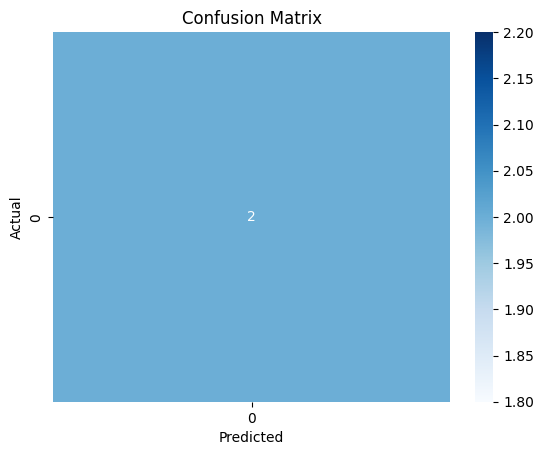

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()